**CENTRALIZED**

Implementation of the centralized model that runs on the server side.

For Helath Related Issues, we usually should use high interpretability models, but in a FL setup, those models do not make much sense, as we work with iterations and GD, that highly suits NN models. This project is not about it, but rather the FL technicality.

In [148]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from IPython.display import display, Markdown
import zipfile

with zipfile.ZipFile('diabetes.zip', 'r') as z:
    print(z.namelist())  # see what's inside
    z.extractall('diabetes_data/')

df = pd.read_csv('diabetes_data/diabetic_data.csv')
print(df.shape)
display(df.head(5))

print(df.count())



['diabetic_data.csv', 'IDS_mapping.csv']
(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


encounter_id                101766
patient_nbr                 101766
race                        101766
gender                      101766
age                         101766
weight                      101766
admission_type_id           101766
discharge_disposition_id    101766
admission_source_id         101766
time_in_hospital            101766
payer_code                  101766
medical_specialty           101766
num_lab_procedures          101766
num_procedures              101766
num_medications             101766
number_outpatient           101766
number_emergency            101766
number_inpatient            101766
diag_1                      101766
diag_2                      101766
diag_3                      101766
number_diagnoses            101766
max_glu_serum                 5346
A1Cresult                    17018
metformin                   101766
repaglinide                 101766
nateglinide                 101766
chlorpropamide              101766
glimepiride         

Data preprocessing

In [149]:
df.replace('?', np.nan, inplace=True)

# Check missing values
print(df.isnull().sum().sort_values(ascending=False).head(10))

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
patient_nbr              0
dtype: int64


In [150]:
df.drop(columns=['weight', 'max_glu_serum', 'A1Cresult', 
                  'medical_specialty', 'payer_code', 
                  'encounter_id', 'patient_nbr'], inplace=True)

In [151]:
df.dropna(inplace=True)
print(df.shape)  #  ~98k rows, plenty

(98053, 43)


In [152]:
# Many columns are categorical strings
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].astype('category').apply(lambda x: x.cat.codes)

/tmp/ipykernel_2164/1094666489.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [153]:
df['readmitted_binary'] = (df['readmitted'] == 0).astype(int)
df.drop(columns=['readmitted'], inplace=True)

print(df['readmitted_binary'].value_counts())

readmitted_binary
0    86987
1    11066
Name: count, dtype: int64


In [154]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X = df.drop(columns=['readmitted_binary']).values
y = df['readmitted_binary'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled     = scaler.transform(X_test)

# Same data prep
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=1024, shuffle=True)

In [155]:
# Simple MLP
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=100, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

In [156]:
from sklearn.utils.class_weight import compute_class_weight


input_dim = X_train_scaled.shape[1]  
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLP(input_dim=input_dim, hidden_dim=100, output_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)


In [157]:
# Training loop

for epoch in range(100):
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

In [158]:
# Eval
model.eval()
with torch.no_grad():
    preds = model(X_test_t.to(device)).argmax(dim=1).cpu().numpy()

from sklearn.metrics import classification_report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.92      0.65      0.76     17408
           1       0.16      0.54      0.25      2203

    accuracy                           0.64     19611
   macro avg       0.54      0.60      0.51     19611
weighted avg       0.83      0.64      0.70     19611



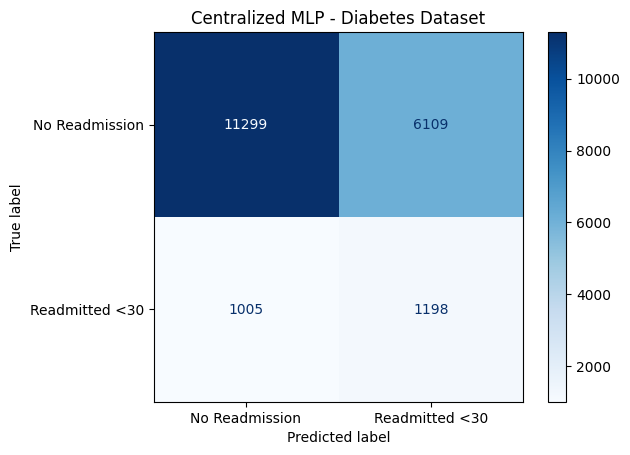

In [159]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    preds = model(X_test_t.to(device)).argmax(dim=1).cpu().numpy()

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Readmission', 'Readmitted <30'])
disp.plot(cmap='Blues')
plt.title('Centralized MLP - Diabetes Dataset')
plt.show()

In [160]:
from sklearn.metrics import classification_report
print(classification_report(y_test, preds, target_names=['No Readmission', 'Readmitted <30']))

                precision    recall  f1-score   support

No Readmission       0.92      0.65      0.76     17408
Readmitted <30       0.16      0.54      0.25      2203

      accuracy                           0.64     19611
     macro avg       0.54      0.60      0.51     19611
  weighted avg       0.83      0.64      0.70     19611

